In [1]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns

# Analyse descriptive du datasetfinal

## 1. Présentation du dataset final

In [2]:
Dataset_final = pd.read_csv("data_final.csv", sep=',', decimal=',')

In [5]:
Dataset_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   etat             384 non-null    str  
 1   matiere          384 non-null    str  
 2   couleur          384 non-null    str  
 3   categorie        384 non-null    str  
 4   likes            384 non-null    str  
 5   prix             384 non-null    str  
 6   prix_total       384 non-null    str  
 7   collection       384 non-null    str  
 8   prix_moyen_zara  384 non-null    str  
 9   decote           384 non-null    str  
dtypes: str(10)
memory usage: 30.1 KB


# 2. Analyse des variables quantitatives

In [15]:
colonnes_num = ["likes", "prix", "prix_total", "prix_moyen_zara", "decote"]

Dataset_final[colonnes_num].describe()

,likes,prix,prix_total,prix_moyen_zara,decote
count,384.000000,384.000000,384.000000,384.000000,384.000000
mean,29.268229,13.994453,15.353698,33.135282,0.467696
std,32.476035,16.269817,17.232584,21.033422,0.693920
min,0.000000,2.000000,2.800000,6.950000,-5.071119
25%,9.750000,5.000000,5.950000,22.137500,0.335681
50%,19.000000,9.100000,10.170000,29.950000,0.711493
75%,37.000000,15.000000,16.450000,35.950000,0.833102
max,222.000000,175.000000,184.450000,159.000000,0.957983


# 3. Analyse des variables qualitatives

In [16]:
# Analyse descriptive complète des variables qualitatives

colonnes_qualitatives = [
    "categorie",
    "etat",
    "matiere",
    "couleur",
    "collection"
]

for col in colonnes_qualitatives:
    print(f"\n===== {col.upper()} =====")
    print(Dataset_final[col].value_counts())


===== CATEGORIE =====
categorie
hauts et t-shirts                   100
pantalons et leggings                47
manteaux et vestes                   36
jeans                                34
robes                                31
sweats et sweats à capuche           27
chaussures                           27
blazers et tailleurs                 24
jupes                                13
accessoires                           9
combinaisons et combishorts           8
shorts                                8
vêtements de sport                    6
costumes et tenues particulières      4
autres                                3
jupes-shorts                          2
maillots de bain                      2
lingerie et pyjamas                   2
sacs                                  1
Name: count, dtype: int64

===== ETAT =====
etat
très bon état          221
neuf sans étiquette     94
neuf avec étiquette     51
bon état                18
Name: count, dtype: int64

===== MATIERE =====
mat

# 4. Visualisations graphiques

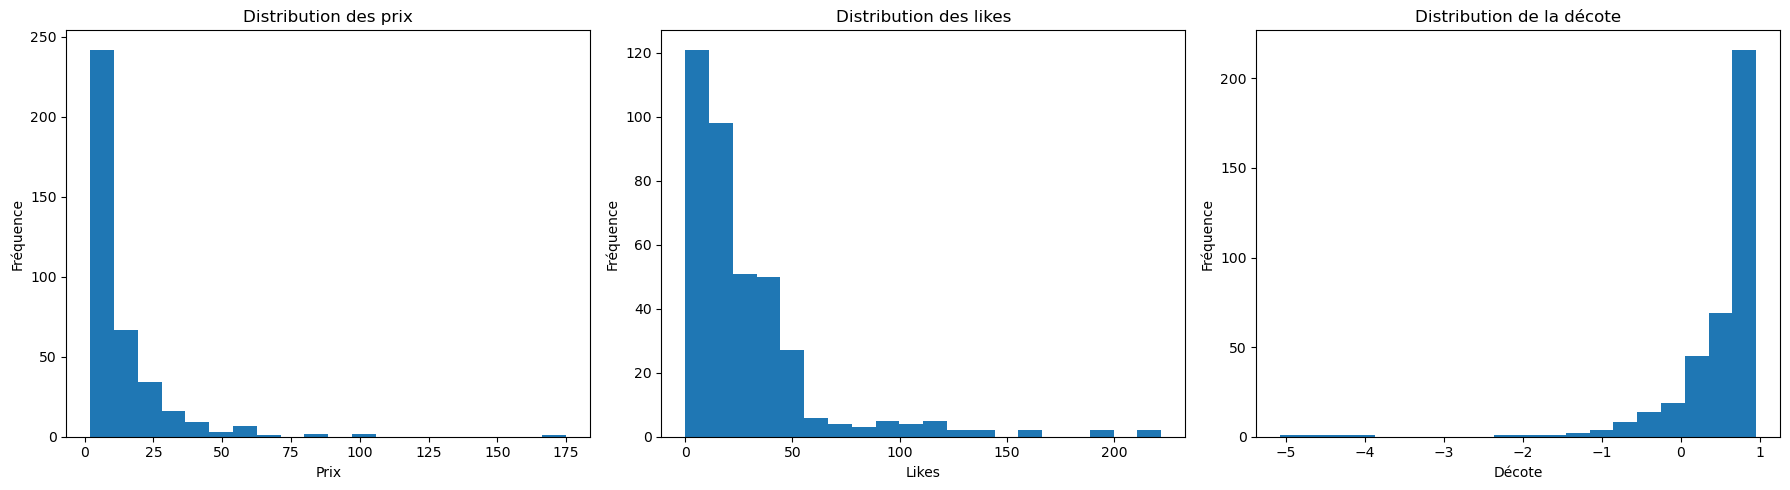

In [24]:
# Création d'une figure avec 2 sous-graphiques
fig, ax = plt.subplots(1, 3, figsize=(18,5))
# Histogramme des prix
ax[0].hist(Dataset_final["prix"], bins=20)
ax[0].set_title("Distribution des prix")
ax[0].set_xlabel("Prix")
ax[0].set_ylabel("Fréquence")
# Histogramme des likes
ax[1].hist(Dataset_final["likes"], bins=20)
ax[1].set_title("Distribution des likes")
ax[1].set_xlabel("Likes")
ax[1].set_ylabel("Fréquence")
# Histogramme de la décote
ax[2].hist(Dataset_final["decote"], bins=20)
ax[2].set_title("Distribution de la décote")
ax[2].set_xlabel("Décote")
ax[2].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

### Diagramme en barres des catégories

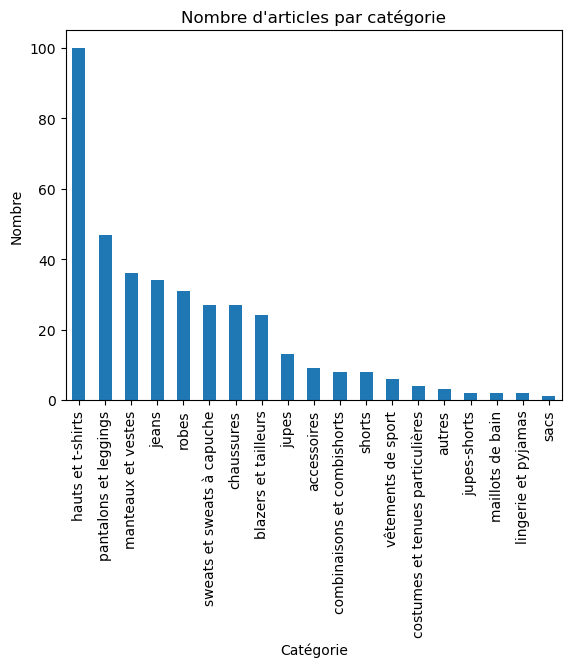

In [21]:
Dataset_final["categorie"].value_counts().plot(kind="bar")

plt.title("Nombre d'articles par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Nombre")

plt.show()

### Diagramme circulaire des états

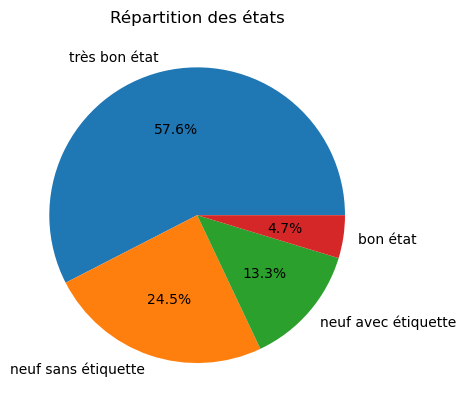

In [22]:
Dataset_final["etat"].value_counts().plot(
    kind="pie",
    autopct='%1.1f%%'
)

plt.title("Répartition des états")
plt.ylabel("")

plt.show()

# 5.Analyses complémentaires

### Prix moyens et décotes moyennes dans une seule figure

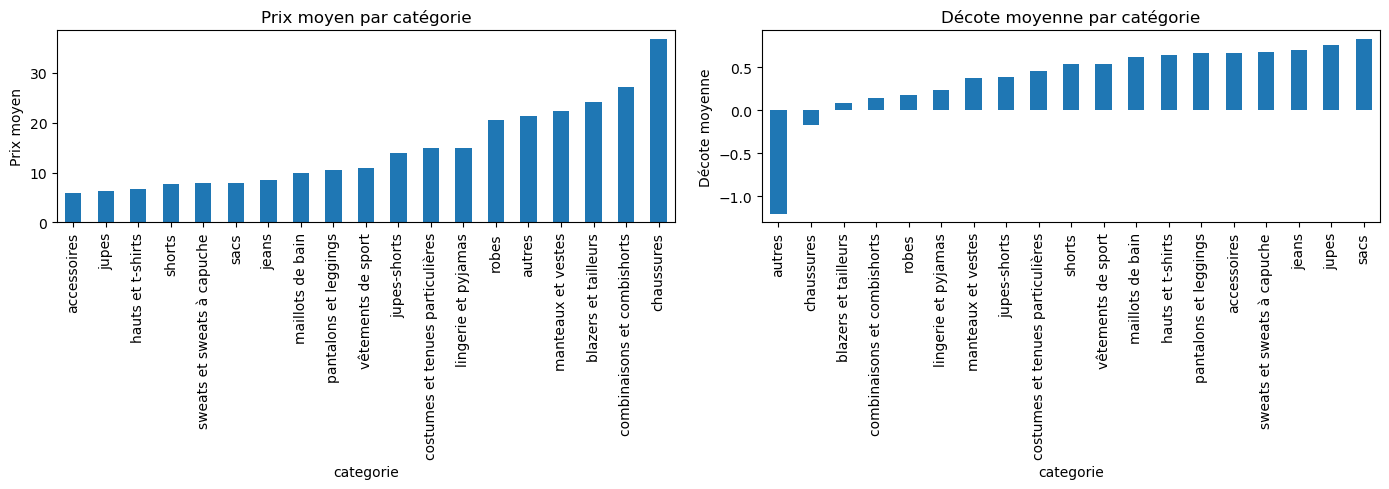

In [25]:

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Prix moyen par catégorie
Dataset_final.groupby("categorie")["prix"].mean().sort_values().plot(
    kind="bar",
    ax=ax[0]
)

ax[0].set_title("Prix moyen par catégorie")
ax[0].set_ylabel("Prix moyen")

# Décote moyenne par catégorie
Dataset_final.groupby("categorie")["decote"].mean().sort_values().plot(
    kind="bar",
    ax=ax[1]
)

ax[1].set_title("Décote moyenne par catégorie")
ax[1].set_ylabel("Décote moyenne")

plt.tight_layout()
plt.show()

### Relations entre variables dans une seule figure

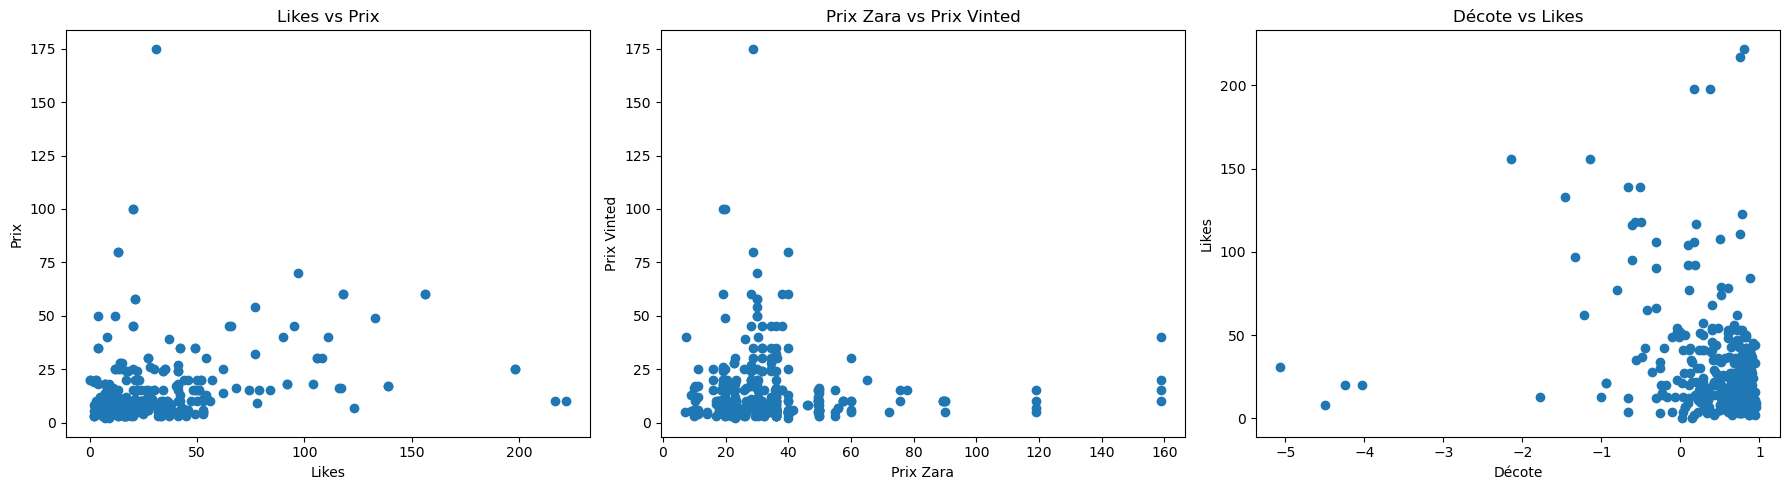

In [26]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

# Likes vs Prix
ax[0].scatter(
    Dataset_final["likes"],
    Dataset_final["prix"]
)

ax[0].set_title("Likes vs Prix")
ax[0].set_xlabel("Likes")
ax[0].set_ylabel("Prix")

# Prix Zara vs Prix Vinted
ax[1].scatter(
    Dataset_final["prix_moyen_zara"],
    Dataset_final["prix"]
)

ax[1].set_title("Prix Zara vs Prix Vinted")
ax[1].set_xlabel("Prix Zara")
ax[1].set_ylabel("Prix Vinted")

# Décote vs Likes
ax[2].scatter(
    Dataset_final["decote"],
    Dataset_final["likes"]
)

ax[2].set_title("Décote vs Likes")
ax[2].set_xlabel("Décote")
ax[2].set_ylabel("Likes")

plt.tight_layout()
plt.show()

# 6. Relation entre variables

### Relation entre likes et prix

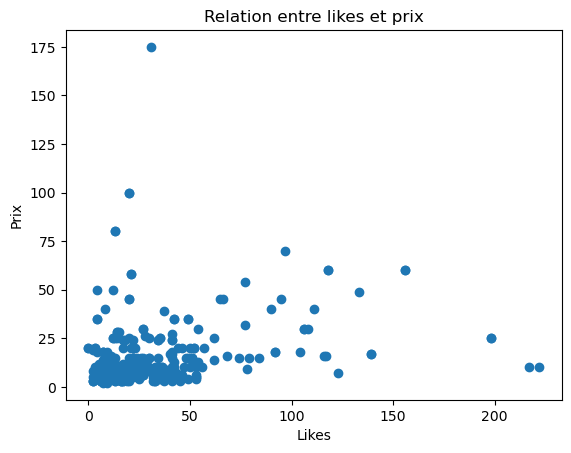

In [27]:
plt.scatter(
    Dataset_final["likes"],
    Dataset_final["prix"]
)

plt.xlabel("Likes")
plt.ylabel("Prix")
plt.title("Relation entre likes et prix")

plt.show()

### Relation entre prix Zara et prix Vinted

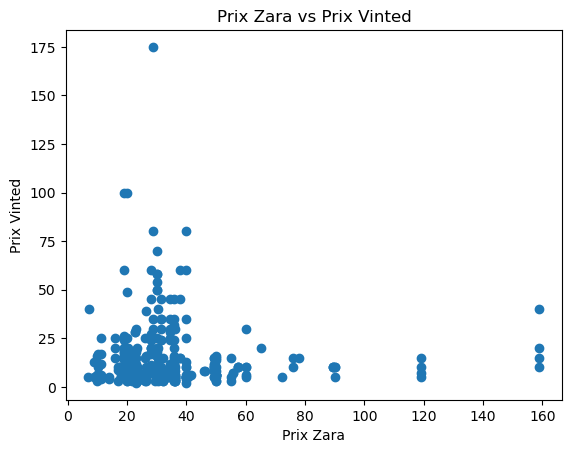

In [28]:
plt.scatter(
    Dataset_final["prix_moyen_zara"],
    Dataset_final["prix"]
)

plt.xlabel("Prix Zara")
plt.ylabel("Prix Vinted")
plt.title("Prix Zara vs Prix Vinted")

plt.show()

### Relation entre décote et likes

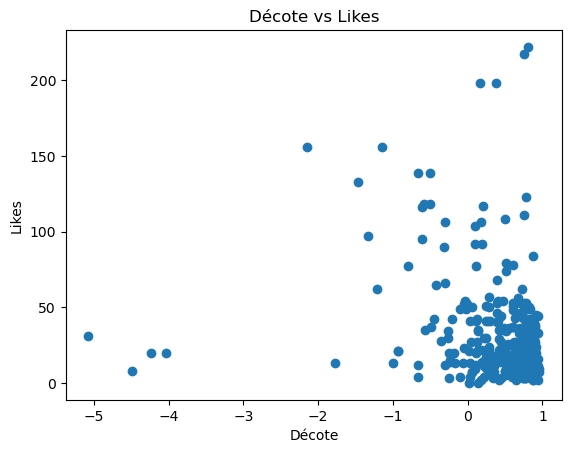

In [29]:
plt.scatter(
    Dataset_final["decote"],
    Dataset_final["likes"]
)

plt.xlabel("Décote")
plt.ylabel("Likes")
plt.title("Décote vs Likes")

plt.show()

# 7. Corrélations

### Matrice de corrélation

In [30]:
Dataset_final[
    [
        "likes",
        "prix",
        "prix_total",
        "prix_moyen_zara",
        "decote"
    ]
].corr()

,likes,prix,prix_total,prix_moyen_zara,decote
likes,1.000000,0.277651,0.278928,0.028973,-0.237530
prix,0.277651,1.000000,0.999928,-0.011538,-0.878252
prix_total,0.278928,0.999928,1.000000,-0.011445,-0.878360
prix_moyen_zara,0.028973,-0.011538,-0.011445,1.000000,0.250290
decote,-0.237530,-0.878252,-0.878360,0.250290,1.000000


### Heatmap des corrélations

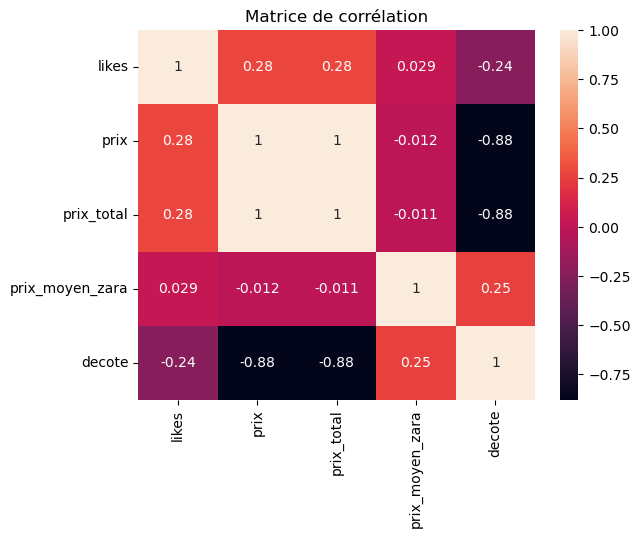

In [31]:

sns.heatmap(
    Dataset_final[
        [
            "likes",
            "prix",
            "prix_total",
            "prix_moyen_zara",
            "decote"
        ]
    ].corr(),
    annot=True
)

plt.title("Matrice de corrélation")

plt.show()